In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
final_table = pd.read_csv("final_table.csv")
final_table.head()

,cluster,target,contig,SQ_gene_content_set,SQ_pathway,SQ_score,taxonomy,bitscore_list,evalue_list
0,63,"GCA_902754915.1_GLIGFB_00196,GCA_902754915.1_G...",CACVLH010000001.1,"sqiA,sqiK",sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[182.0, 185.0]","[7.299999999999999e-52, 4.5899999999999996e-55]"
1,66,"GCA_902754915.1_GLIGFB_00381,GCA_902754915.1_G...",CACVLH010000002.1,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[142.0, 217.0, 162.0, 291.0, 298.0, 255.0]","[1.6599999999999999e-40, 5.99e-66, 3.31e-50, 1..."
2,271,"GCA_902755405.1_GNFANA_00528,GCA_902755405.1_G...",CACVMX010000032.1,"sqvA,sqwG,sqwH",sulfo-TAL,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[232.0, 227.0, 148.0]","[2.86e-74, 1.79e-71, 3.93e-43]"
3,387,"GCA_902755455.1_HAJFOH_00002,GCA_902755455.1_H...",CACVNO010000001.1,"sqiA,sqiK",sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[160.0, 182.0]","[1.03e-45, 7.299999999999999e-52]"
4,392,"GCA_902755455.1_HAJFOH_00507,GCA_902755455.1_H...",CACVNO010000004.1,"sqvD,sqwF,sqwG,sqwH,sqwI,yihQ",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[391.0, 275.0, 295.0, 292.0, 159.0, 206.0]","[1.12e-125, 1.51e-86, 3.47e-99, 8.999999999999..."


In [3]:
# Извлекаем phylum
final_table["phylum"] = final_table["taxonomy"].str.extract(r"p__([^;]+)")

# Считаем локусы для каждой пары путь/таксон и сортируем
phylum_counts = final_table.groupby(["SQ_pathway", "phylum"]).size().reset_index(name="count")
phylum_counts_sorted = phylum_counts.sort_values("count", ascending=False).reset_index(drop=True)

print(phylum_counts_sorted)

    SQ_pathway             phylum  count
0    sulfo-EMP          Bacillota    151
1    sulfo-TAL          Bacillota    150
2     sulfo-TK          Bacillota     50
3    sulfo-TAL     Actinomycetota     10
4    sulfo-TAL     Pseudomonadota      9
5    sulfo-EMP      Chloroflexota      8
6    sulfo-TAL   Thermoplasmatota      5
7   sulfo-ASMO     Actinomycetota      5
8    sulfo-EMP      Spirochaetota      4
9    sulfo-TAL      Chloroflexota      3
10    sulfo-TK      Spirochaetota      2
11   sulfo-EMP     Actinomycetota      2
12    sulfo-ED          Bacillota      1
13   sulfo-EMP  Verrucomicrobiota      1


In [4]:
# Извлекаем class
final_table["class"] = final_table["taxonomy"].str.extract(r"c__([^;]+)")

# Считаем локусы для каждой пары путь/таксон и сортируем
class_counts = final_table.groupby(["SQ_pathway", "class"]).size().reset_index(name="count")
class_counts_sorted = class_counts.sort_values("count", ascending=False).reset_index(drop=True)

print(class_counts_sorted)

    SQ_pathway                class  count
0    sulfo-EMP           Clostridia    145
1    sulfo-TAL           Clostridia    132
2     sulfo-TK           Clostridia     50
3    sulfo-TAL              Bacilli     13
4    sulfo-TAL       Coriobacteriia     10
5    sulfo-TAL  Gammaproteobacteria      9
6    sulfo-EMP         Anaerolineae      8
7    sulfo-EMP              Bacilli      6
8    sulfo-TAL       Thermoplasmata      5
9   sulfo-ASMO        Actinomycetes      5
10   sulfo-EMP         Spirochaetia      4
11   sulfo-TAL         Anaerolineae      3
12   sulfo-TAL        Negativicutes      3
13   sulfo-TAL      Dehalobacteriia      2
14    sulfo-TK         Spirochaetia      2
15   sulfo-EMP       Coriobacteriia      2
16    sulfo-ED           Clostridia      1
17   sulfo-EMP      Kiritimatiellia      1


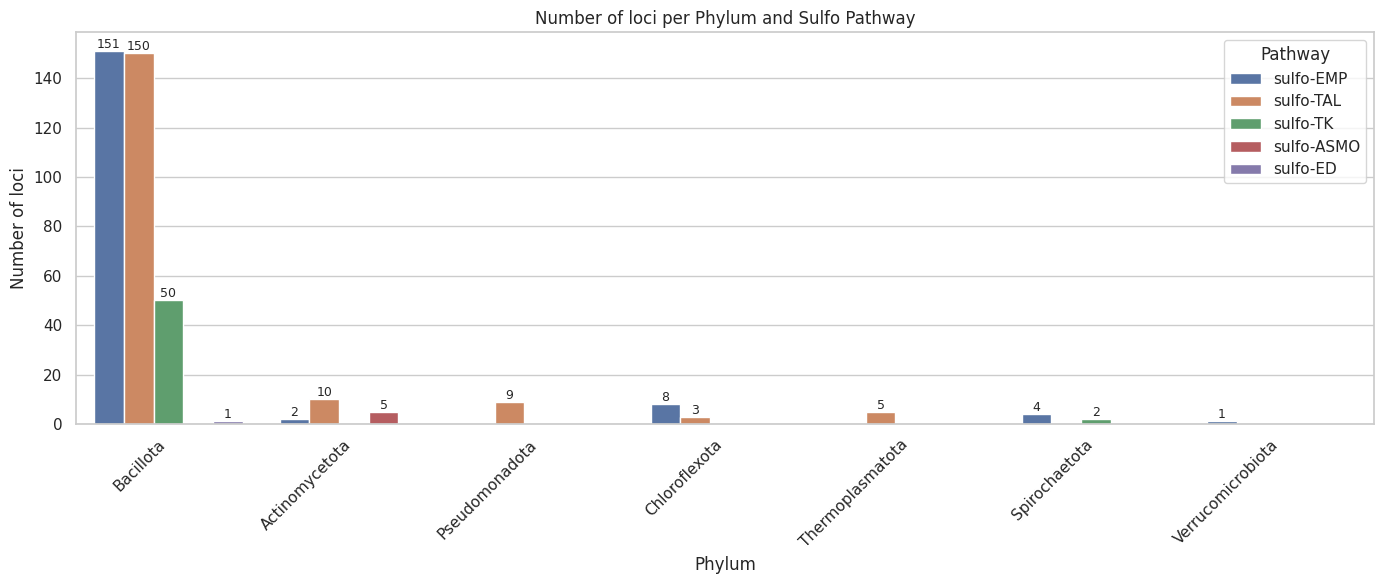

In [6]:
# Используем готовую таблицу со всеми count
plot_df = phylum_counts_sorted.copy()  # phylum, SQ_pathway, count

# Настройка графика
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Столбцы: x = phylum, y = count, цвет = путь
ax = sns.barplot(data=plot_df, x="phylum", y="count", hue="SQ_pathway", dodge=True)

# Подписи значений Y над столбцами (только если count > 0)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',  # текст подписи
            (p.get_x() + p.get_width() / 2., height),  # координаты: центр и вершина столбца
            ha='center', va='bottom', fontsize=9
        )

# Настройка подписей осей и заголовка
plt.xticks(rotation=45, ha="right")
plt.xlabel("Phylum")
plt.ylabel("Number of loci")
plt.title("Number of loci per Phylum and Sulfo Pathway")
plt.legend(title="Pathway")
plt.tight_layout()

# --- Сохраняем график ---
plt.savefig("pictures/phyla_visualisation/pathways_by_phylum.png", dpi=300)  # PNG с высоким разрешением
# plt.savefig("sulfo_pathways_by_phylum.pdf")  # альтернатива PDF

plt.show()

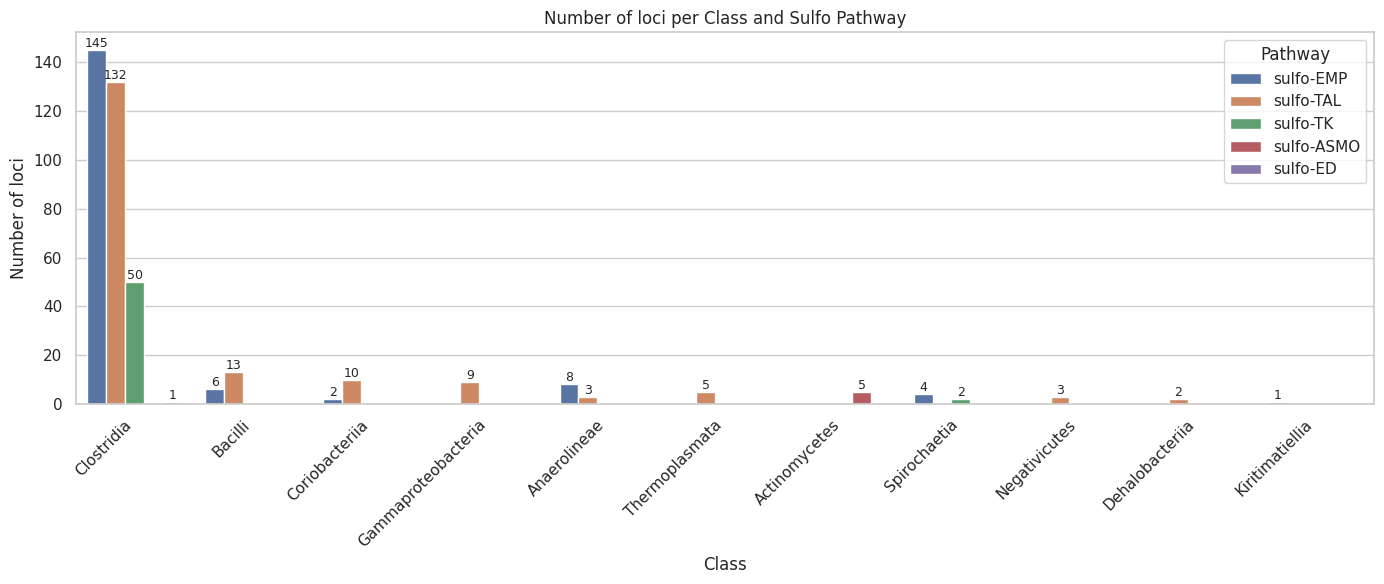

In [7]:
# Используем готовую таблицу со всеми count
plot_df = class_counts_sorted.copy()  # phylum, SQ_pathway, count

# Настройка графика
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Столбцы: x = phylum, y = count, цвет = путь
ax = sns.barplot(data=plot_df, x="class", y="count", hue="SQ_pathway", dodge=True)

# Подписи значений Y над столбцами (только если count > 0)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',  # текст подписи
            (p.get_x() + p.get_width() / 2., height),  # координаты: центр и вершина столбца
            ha='center', va='bottom', fontsize=9
        )

# Настройка подписей осей и заголовка
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of loci")
plt.title("Number of loci per Class and Sulfo Pathway")
plt.legend(title="Pathway")
plt.tight_layout()

# --- Сохраняем график ---
plt.savefig("pictures/phyla_visualisation/pathways_by_class.png", dpi=300)  # PNG с высоким разрешением
# plt.savefig("sulfo_pathways_by_phylum.pdf")  # альтернатива PDF

plt.show()

In [8]:
class_counts_sorted.head(10)

,SQ_pathway,class,count
0,sulfo-EMP,Clostridia,145
1,sulfo-TAL,Clostridia,132
2,sulfo-TK,Clostridia,50
3,sulfo-TAL,Bacilli,13
4,sulfo-TAL,Coriobacteriia,10
5,sulfo-TAL,Gammaproteobacteria,9
6,sulfo-EMP,Anaerolineae,8
7,sulfo-EMP,Bacilli,6
8,sulfo-TAL,Thermoplasmata,5
9,sulfo-ASMO,Actinomycetes,5


ДАЛЬШЕ ШЛЯПА

In [ ]:
# Извлекаем mag_id из target
final_table["mag_id"] = final_table["target"].str.extract(r"(GCA_\d+\.\d+)")

# Группируем по MAG
mag_summary = final_table.groupby("mag_id").agg({
    "SQ_pathway": lambda x: list(x.dropna()),
    "SQ_score": lambda x: list(x.dropna()),
    "taxonomy": "first"  # предполагаем, что таксономия одинаковая внутри MAG
}).reset_index()

# (опционально) убираем дубликаты путей внутри MAG
mag_summary["SQ_pathway"] = mag_summary["SQ_pathway"].apply(lambda x: list(set(x)))
mag_summary["SQ_score"] = mag_summary["SQ_score"].apply(lambda x: list(set(x)))

print(mag_summary)

In [ ]:
# pathways (dict)
def make_pathway_dict(df):
    return dict(zip(df["SQ_pathway"], df["SQ_score"]))

mag_summary = final_table.groupby("mag_id").apply(make_pathway_dict).reset_index(name="pathways")

# добавим таксономию
taxonomy_map = final_table.groupby("mag_id")["taxonomy"].first().reset_index()
mag_summary = mag_summary.merge(taxonomy_map, on="mag_id")

print(mag_summary.head())

In [ ]:
# разворачиваем pathways в строки
rows = []
for _, row in mag_summary.iterrows():
    for pathway, score in row["pathways"].items():
        rows.append({
            "mag_id": row["mag_id"],
            "pathway": pathway,
            "score": score,
            "taxonomy": row["taxonomy"]
        })

long_df = pd.DataFrame(rows)

In [ ]:
presence_matrix = pd.crosstab(long_df["mag_id"], long_df["pathway"])

In [ ]:
score_map = {
    "min": 1,
    "min_up": 2,
    "min_down": 2,
    "max": 3
}

long_df["score_num"] = long_df["score"].map(score_map)

score_matrix = long_df.pivot_table(
    index="mag_id",
    columns="pathway",
    values="score_num",
    fill_value=0
)

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(score_matrix, cmap="viridis")

plt.title("MAG × Sulfo Pathways (score)")
plt.xlabel("Pathway")
plt.ylabel("MAG")
plt.tight_layout()

plt.savefig("heatmap_MAG_pathways.png", dpi=300)
plt.show()

In [ ]:
long_df["phylum"] = long_df["taxonomy"].str.extract(r"p__([^;]+)")

In [ ]:
phylum_counts = pd.crosstab(long_df["phylum"], long_df["pathway"])
print(phylum_counts)

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(phylum_counts, annot=True, fmt="d")

plt.title("Pathway distribution across phyla")
plt.xlabel("Pathway")
plt.ylabel("Phylum")

plt.tight_layout()
plt.savefig("heatmap_phylum_pathways.png", dpi=300)
plt.show()